# Does English de-censoring also unlock Slovene? — `method.py` demo

This notebook is the entry point (`method.py`) of the **dir5 / SCREEN-SPEC v1** experiment, split into cells with explanations.

**What the experiment did.** One pinned **Heretic** abliteration run (p-e-w/heretic@3521f864), optimising a purely **English** objective
(keyword refusals + KL divergence), was applied with identical config, NF4 4-bit precision and the same seeded TPE sampler to

* `google/gemma-3-12b-it`, the control, and
* `cjvt/GaMS3-12B-Instruct`, the Slovene-adapted continuation of Gemma 3.

Both the edited and unedited models were then scored on **400 RefusEU English/Slovene prompt pairs** with a frozen refusal lexicon (`R`), a refusal log-odds readout (`s`, `s1`), 5-token compliant prefills, and an LLM judge.

**What `method.py` itself does.** It orchestrates the pipeline and then assembles `method_out.json`:

```
S0  prep_data.py / write_protocol.py      (data + frozen protocol)
GPU run_all.sh -> run_model.py            (hours on a 16 GB GPU: Heretic TPE trials, scoring, prefill)
J   judge.py                              (OpenRouter judge)
A   analyze.py -> make_figs.py -> build_method_out() -> method_out.json
```

**What this demo runs.** The GPU and judge stages need two 12B models and an API key, so they are **off** here (`RUN_GPU = RUN_JUDGE = False`, the same as running `method.py` with no flags).
This demo does the following:
1. It loads `mini_demo_data.json`: 25 RefusEU pairs, stratified over the 14 harm categories, with each model's saved original, edited and prefill generations, judge labels, all TPE trials, and the saved `analysis.json`.
2. It rebuilds the artifact's `results/` folder layout from that data.
3. It runs the original `build_method_out()` **unchanged** to produce `method_out.json`.
4. It plots the key comparisons.

Headline full-run findings (from `analysis.json`): lexicon refusal falls 0.965→0.242 EN / 0.932→0.223 SL on Gemma and 0.940→0.133 EN / 0.830→0.098 SL on GaMS.
The English edit therefore **does** reach Slovene in both models. Slovene is *more* exposed in GaMS (G3 = −1.86), and 5-token prefills flip GaMS far more often than Gemma.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (used by the artifact's setup_logger)
_pip('loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

## Imports
The original import block from `method.py`, plus `os`/`numpy`/`matplotlib` for the demo. The original line
`from common import RESULTS, SPLITS, read_jsonl, setup_logger` imported from `src/common.py`, which is not shipped with the notebook.
Those helpers are copied verbatim from `src/common.py` in a later cell.

In [2]:
from __future__ import annotations

import argparse
import json
import subprocess
import sys
from pathlib import Path

# --- additional imports for the notebook demo ---
import os
import numpy as np
import matplotlib.pyplot as plt

## Load the demo data
The data comes from GitHub, with a fallback to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2cf2a7-does-slovene-taught-refusal-survive/fork/run_03_dodOtFxiE/round-1/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("pairs:", len(data["score400"]), "| models:", list(data["results"]))

Curated subset of the dir5 artifact (English-objective Heretic abliteration on Gemma-3-12B-IT vs GaMS3-12B-Instruct): 25 RefusEU SCORE-400 EN/SL pairs (round-robin over categories) with per-model original/selected/prefill generations (texts truncated to 700 chars), judge labels, all Heretic TPE trials, and the saved analysis.json.
pairs: 25 | models: ['gemma_it', 'gams3_it']


## Config
These values replace `method.py`'s command-line flags (`--run-gpu`, `--judge`) and set the demo's size.

* `N_PAIRS` sets how many of the 25 curated RefusEU pairs are written into the rebuilt `results/` folder. The original run used **400** pairs (`score400.jsonl`), which is the value to use for a full run.
* `RUN_GPU` / `RUN_JUDGE` / `RUN_ANALYZE` are the pipeline stages. The original defaults are `False`/`False`, and `analyze.py` + `make_figs.py` always ran. They stay off here because they need the GPU-produced per-item files (≈40 MB of trial KL/probe logs) and the `src/` scripts.

In [5]:
N_PAIRS = 25          # curated RefusEU pairs to materialise (max 25 in mini_demo_data.json; original run: 400)
RUN_GPU = False       # original flag --run-gpu  (runs ./run_all.sh: ~2 x 1.5 h on a 16 GB GPU)
RUN_JUDGE = False     # original flag --judge    (OpenRouter gemini-2.5-flash judge; needs an API key)
RUN_ANALYZE = False   # original: always ran src/analyze.py + src/make_figs.py; here analysis.json is loaded from the saved run

## Rebuild the artifact's file layout from `data`
`build_method_out()` reads files under `results/` and `data/splits/`. Rather than editing the function, this cell writes the demo subset back into that same layout inside `./dir5_workspace/`:

| file | content |
|---|---|
| `data/splits/score400.jsonl` | the EN/SL RefusEU prompt pairs |
| `results/<model>/orig_score400.jsonl` | unedited model generations + `R` (lexicon refusal), `s`, `s1` (refusal log-odds) |
| `results/<model>/selected_score400.jsonl` | generations of the Heretic-selected edit |
| `results/<model>/prefill.jsonl` | continuations after a 5/10/20-token compliant prefill (`flip` = refusal turned into compliance) |
| `results/<model>/trials.json` | the TPE trials (English objective + logged bilingual metrics) |
| `results/judge.jsonl` | LLM-judge labels |
| `results/analysis.json` | the saved full-run analysis (C3, C5, ALT-4 statistics) |

The judge cost ledger (3.8 MB) is replaced by a single row carrying its saved total.

In [6]:
WS = Path("dir5_workspace").resolve()   # stands in for the artifact workspace (method.py: WS = Path(__file__).resolve().parent)

def _write_jsonl(p: Path, rows):
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))

_pairs = data["score400"][:N_PAIRS]
_ids = {p["pair_id"] for p in _pairs}
_write_jsonl(WS / "data" / "splits" / "score400.jsonl", _pairs)
for _m, _r in data["results"].items():
    for _name in ["orig_score400", "selected_score400", "prefill"]:
        _write_jsonl(WS / "results" / _m / f"{_name}.jsonl", [r for r in _r[_name] if r["pair_id"] in _ids])
    for _name in ["trials", "checks", "selection_pick", "random_edits", "lambda_curve"]:
        (WS / "results" / _m / f"{_name}.json").write_text(json.dumps(_r[_name], ensure_ascii=False))
_write_jsonl(WS / "results" / "judge.jsonl", [r for r in data["judge"] if r["pair_id"] in _ids])
_write_jsonl(WS / "results" / "judge_ledger.jsonl", [{"note": "aggregated full-run ledger", "cost": data["judge_ledger_total_cost_usd"]}])
(WS / "results" / "analysis.json").write_text(json.dumps(data["analysis"], ensure_ascii=False))
(WS / "results" / "protocol_amendments.json").write_text(json.dumps(data["protocol_amendments"], ensure_ascii=False))
(WS / "protocol.sha256").write_text(data["protocol_sha256"])
print(sorted(str(p.relative_to(WS)) for p in WS.rglob("*") if p.is_file()))

['data/splits/score400.jsonl', 'logs/method.log', 'method_out.json', 'protocol.sha256', 'results/analysis.json', 'results/gams3_it/checks.json', 'results/gams3_it/lambda_curve.json', 'results/gams3_it/orig_score400.jsonl', 'results/gams3_it/prefill.jsonl', 'results/gams3_it/random_edits.json', 'results/gams3_it/selected_score400.jsonl', 'results/gams3_it/selection_pick.json', 'results/gams3_it/trials.json', 'results/gemma_it/checks.json', 'results/gemma_it/lambda_curve.json', 'results/gemma_it/orig_score400.jsonl', 'results/gemma_it/prefill.jsonl', 'results/gemma_it/random_edits.json', 'results/gemma_it/selected_score400.jsonl', 'results/gemma_it/selection_pick.json', 'results/gemma_it/trials.json', 'results/judge.jsonl', 'results/judge_ledger.jsonl', 'results/protocol_amendments.json']


## Helpers from `src/common.py`
These are the paths and the two helpers that `method.py` imported. `read_jsonl` and `setup_logger` are copied verbatim.

In [7]:
DATA = WS / "data"
SPLITS = DATA / "splits"
RESULTS = Path(os.environ.get("AII_RESULTS", str(WS / "results")))  # env override only for tests
LOGS = WS / "logs"
for _d in (DATA, SPLITS, RESULTS, LOGS):
    _d.mkdir(parents=True, exist_ok=True)


def read_jsonl(p: Path) -> list[dict]:
    if not p.exists():
        return []
    out = []
    for line in p.read_text().splitlines():
        line = line.strip()
        if line:
            out.append(json.loads(line))
    return out


def setup_logger(name: str):
    from loguru import logger
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(str(LOGS / f"{name}.log"), rotation="30 MB", level="DEBUG")
    return logger

## Setup from `method.py`
The logger, the path to the artifact's own venv interpreter, and the `run()` helper that launches a pipeline stage inside `src/`.

In [8]:
logger = setup_logger("method")
PY = str(WS / ".venv" / "bin" / "python")


def run(cmd: list[str]):
    logger.info("run: " + " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=WS / "src")

## `build_method_out()` (verbatim)
This is the core of `method.py`. For each model it joins, per RefusEU `(pair_id, lang)`:
* the **original** model output with its lexicon refusal `R`, the refusal log-odds `s` (multi-token) and `s1` (first-token);
* the output of the **Heretic-selected** English-objective edit (`R_selected`, `s_selected`);
* the **5-token compliant prefill** continuation and whether it flipped a refusal (`prefill5_flip`);
* the **LLM-judge** labels, and for Slovene whether the model answered in Slovene (`sl_consistent`).

It then adds one example per **TPE trial**. The trial's input is the edit parameters. Its output is the English objective (keyword refusals, KL). The bilingual probe is logged alongside and **never enters the objective**.

The metadata block collects the analysis, selection picks, random-direction controls and λ dose curves.

In [9]:
def build_method_out() -> dict:
    A = json.loads((RESULTS / "analysis.json").read_text())
    s400 = {p["pair_id"]: p for p in read_jsonl(SPLITS / "score400.jsonl")}
    judge = {}
    for r in read_jsonl(RESULTS / "judge.jsonl"):
        judge[(r["model"], r["cell"], r["lang"], r["pair_id"], r["trial"])] = r["judge"]
    datasets = []
    for m in A["models_available"]:
        orig = {(r["pair_id"], r["lang"]): r for r in read_jsonl(RESULTS / m / "orig_score400.jsonl")}
        sel = {(r["pair_id"], r["lang"]): r for r in read_jsonl(RESULTS / m / "selected_score400.jsonl") if "s" in r}
        pre = {(r["pair_id"], r["lang"]): r for r in read_jsonl(RESULTS / m / "prefill.jsonl") if r["k"] == 5}
        ex = []
        for (pid, lang), o in orig.items():
            s = sel.get((pid, lang), {})
            e = {"input": s400[pid][lang], "output": o.get("text", ""),
                 "predict_heretic_selected_edit": s.get("text", ""),
                 "predict_prefill5_continuation": (pre[(pid, lang)]["prefill"] + pre[(pid, lang)]["text"]) if (pid, lang) in pre else "",
                 "metadata_model": m, "metadata_pair_id": pid, "metadata_lang": lang,
                 "metadata_category": o["category"], "metadata_dose_group": o["dose_group"],
                 "metadata_R_orig": o.get("R"), "metadata_s_orig": o["s"], "metadata_s1_orig": o["s1"],
                 "metadata_R_selected": s.get("R"), "metadata_s_selected": s.get("s"),
                 "metadata_prefill5_flip": pre[(pid, lang)]["flip"] if (pid, lang) in pre else None,
                 "metadata_judge_orig": judge.get((m, "orig", lang, pid, -1)),
                 "metadata_judge_selected": judge.get((m, "selected", lang, pid, -1))}
            if lang == "sl":
                e["metadata_sl_consistent_orig"] = o.get("sl_consistent")
                e["metadata_sl_consistent_selected"] = s.get("sl_consistent")
            ex.append(e)
        datasets.append({"dataset": f"RefusEU_SCORE400_{m}", "examples": ex})
        tr = json.loads((RESULTS / m / "trials.json").read_text()) if (RESULTS / m / "trials.json").exists() else []
        tex = []
        for t in tr:
            ua = t["user_attrs"]
            tex.append({"input": json.dumps({"direction_index": ua.get("direction_index"), "parameters": ua.get("parameters")}),
                        "output": json.dumps({"keyword_refusals": t["values"][0], "kl": t["values"][1]}),
                        "predict_bilingual_probe": json.dumps(ua.get("bilingual", {})),
                        "metadata_model": m, "metadata_trial_index": ua.get("index"), "metadata_number": t["number"]})
        if tex:
            datasets.append({"dataset": f"Heretic_trials_{m}", "examples": tex})
    meta = {"method_name": "English-objective Heretic abliteration: bilingual reach (GaMS3 vs Gemma-3 control)",
            "artifact": "gen_art_experiment_4 (dir5), run_FVi3e3O9CH5I iter_1, SCREEN-SPEC v1",
            "precision": "NF4 reduced precision (bitsandbytes 4-bit, double quant, bf16 compute) for both models",
            "protocol_sha256": (WS / "protocol.sha256").read_text().split()[0],
            "protocol_amendments": json.loads((RESULTS / "protocol_amendments.json").read_text()) if (RESULTS / "protocol_amendments.json").exists() else None,
            "analysis": A,
            "checks": {m: json.loads((RESULTS / m / "checks.json").read_text()) for m in A["models_available"] if (RESULTS / m / "checks.json").exists()},
            "selection_picks": {m: json.loads((RESULTS / m / "selection_pick.json").read_text()) for m in A["models_available"] if (RESULTS / m / "selection_pick.json").exists()},
            "random_edits": {m: json.loads((RESULTS / m / "random_edits.json").read_text()) for m in A["models_available"] if (RESULTS / m / "random_edits.json").exists()},
            "lambda_curves": {m: json.loads((RESULTS / m / "lambda_curve.json").read_text()) for m in A["models_available"] if (RESULTS / m / "lambda_curve.json").exists()},
            "openrouter_spend_usd": sum(float(r.get("cost", 0) or 0) for r in read_jsonl(RESULTS / "judge_ledger.jsonl")),
            "per_item_files": sorted(str(p) for p in RESULTS.rglob("*.jsonl") if "smoke" not in str(p))}
    return {"metadata": meta, "datasets": datasets}

## `main()`
This is the original `main()`, with the `argparse` flags replaced by the config variables. The GPU, judge and analysis stages are skipped when their flag is `False`. The final assembly and the write of `method_out.json` are unchanged.

In [10]:
def main():
    # original: ap = argparse.ArgumentParser(); --run-gpu / --judge  -> replaced by RUN_GPU / RUN_JUDGE config flags
    if RUN_GPU:
        subprocess.run([str(WS / "run_all.sh")], check=True)
    if RUN_JUDGE:
        run([sys.executable, "judge.py"])
    if RUN_ANALYZE:  # original: always ran (needs src/ and the full per-item GPU logs)
        run([PY, "analyze.py"])
        run([PY, "make_figs.py"])
    out = build_method_out()
    (WS / "method_out.json").write_text(json.dumps(out, indent=1, ensure_ascii=False, default=float))
    logger.info(f"method_out.json: {sum(len(d['examples']) for d in out['datasets'])} examples in {len(out['datasets'])} datasets")
    return out


out = main()

17:41:28|INFO   |method_out.json: 137 examples in 4 datasets


## Results and visualisation
1. **Refusal before and after the English-objective edit.** This shows lexicon refusal `R` for each model × language on the demo pairs, next to the saved full 400-pair rates from `analysis.json`.
2. **Prefill flips.** This is the share of original refusals that a 5-token compliant prefill turns into compliance (ALT-4).
3. **Trial-level EN→SL coupling.** Each Heretic TPE trial logged EN and SL refusal on the 50+50 probe items. The plot shows logit(SL) vs logit(EN) with the `hautus` correction `(k+.5)/(n+1)` from `analyze.py`. This plain OLS fit over all trials gives the same point slopes as the saved all-trials C3 fit (Gemma 1.14, GaMS 0.79). The headline C3 numbers (matched first 17 trials: Gemma 1.21, GaMS 0.79, G3 = −1.86) and their bootstrap CIs are read from `analysis.json`. The vertical offset between the two lines is what G3 measures: at equal English refusal, GaMS refuses less in Slovene.

model     lang   n | R_orig  R_sel | full R_orig full R_sel | prefill5 flip
gemma_it  en    25 |  0.880  0.200 |       0.965      0.242 | demo 0.00 / full 0.031
gemma_it  sl    25 |  0.920  0.120 |       0.932      0.223 | demo 0.57 / full 0.558
gams3_it  en    25 |  0.880  0.120 |       0.940      0.133 | demo 0.64 / full 0.559
gams3_it  sl    25 |  0.840  0.040 |       0.830      0.098 | demo 0.90 / full 0.855

Saved C3 (matched first-17 trials): G3 = a_GaMS - a_Gemma = -1.86  CI95 [-2.87, -1.13]  (MAIN needs |G3| < m = 0.675; EN->SL slopes Gemma 1.21, GaMS 0.79)
Saved ALT-4: Sig_EN = 3.63, Sig_SL = 1.54, z_c = 6.23, survives = False
Selected trial gemma_it: #8 keyword refusals 0.64, KL 0.366 (selection_rule_fallback)
Selected trial gams3_it: #8 keyword refusals 0.29, KL 0.233 (selection_rule_fallback)


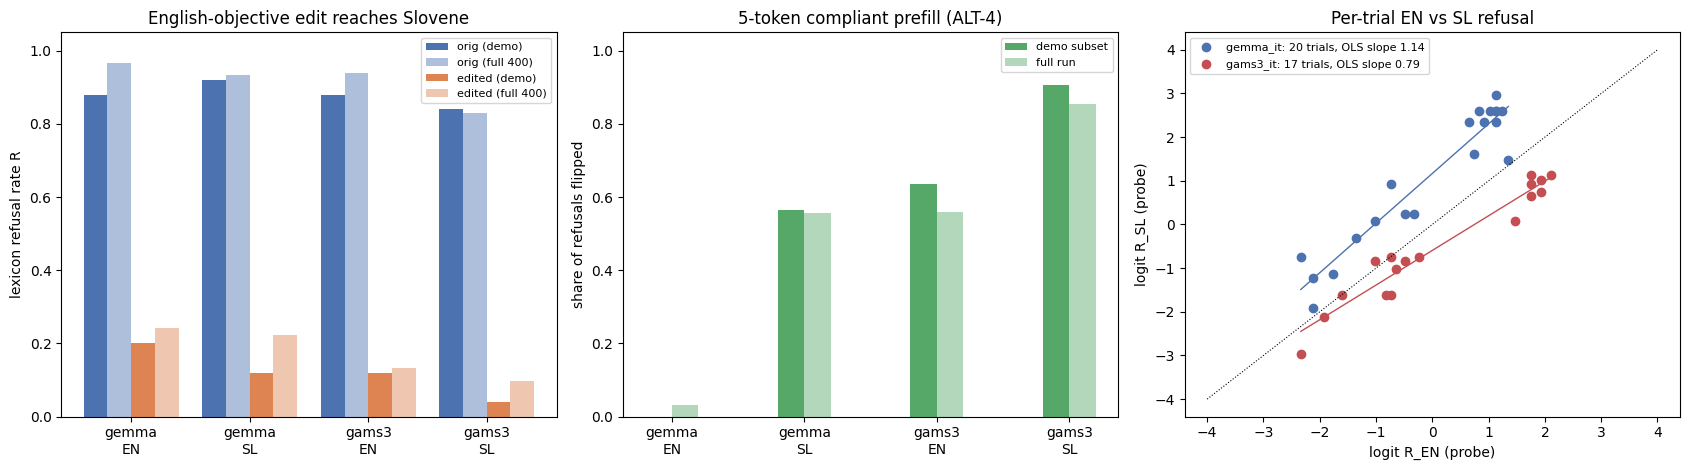

In [11]:
A = out["metadata"]["analysis"]
models = A["models_available"]
ex = {d["dataset"]: d["examples"] for d in out["datasets"]}

# ---- 1. refusal rates on the demo subset vs saved full-run rates ----
rows = []
print(f"{'model':9s} {'lang':4s} {'n':>3s} | {'R_orig':>6s} {'R_sel':>6s} | {'full R_orig':>11s} {'full R_sel':>10s} | {'prefill5 flip':>13s}")
for m in models:
    for lang in ["en", "sl"]:
        E = [e for e in ex[f"RefusEU_SCORE400_{m}"] if e["metadata_lang"] == lang]
        r0 = np.mean([e["metadata_R_orig"] for e in E if e["metadata_R_orig"] is not None])
        r1 = np.mean([e["metadata_R_selected"] for e in E if e["metadata_R_selected"] is not None])
        fl = [e["metadata_prefill5_flip"] for e in E if e["metadata_prefill5_flip"] is not None]
        f0 = A["P0_descriptives"][f"{m}|orig|{lang}"]["R"]; f1 = A["P0_descriptives"][f"{m}|selected|{lang}"]["R"]
        fr = A["ALT4"]["prefill_signature"]["Sig"][lang]["flip_rate"][m]
        rows.append((m, lang, r0, r1, f0, f1, np.mean(fl) if fl else np.nan, fr))
        print(f"{m:9s} {lang:4s} {len(E):3d} | {r0:6.3f} {r1:6.3f} | {f0:11.3f} {f1:10.3f} | demo {np.mean(fl) if fl else float('nan'):.2f} / full {fr:.3f}")

c3 = A["C3"]["matched_first_k_trials"]["all_pairs"]  # headline C3: first 17 TPE draws, identical across models
print(f"\nSaved C3 (matched first-17 trials): G3 = a_GaMS - a_Gemma = {c3['G3']['est']:.2f}  CI95 {np.round(c3['G3']['ci95'], 2).tolist()}  "
      f"(MAIN needs |G3| < m = {A['m']['m']:.3f}; EN->SL slopes Gemma {c3['b_slope']['gemma_it']['est']:.2f}, GaMS {c3['b_slope']['gams3_it']['est']:.2f})")
print(f"Saved ALT-4: Sig_EN = {A['ALT4']['prefill_signature']['Sig']['en']['est']:.2f}, Sig_SL = {A['ALT4']['prefill_signature']['Sig']['sl']['est']:.2f}, z_c = {A['ALT4']['prefill_signature']['z_c']:.2f}, survives = {A['ALT4']['prefill_signature']['survive']}")
for m in models:
    sp = out["metadata"]["selection_picks"][m]
    print(f"Selected trial {m}: #{sp['pick_trial_index']} keyword refusals {sp['refusals']:.2f}, KL {sp['kl']:.3f} ({sp['flag']})")

fig, axs = plt.subplots(1, 3, figsize=(17, 4.8))
labels = [f"{m.split('_')[0]}\n{l.upper()}" for m, l, *_ in rows]
x = np.arange(len(rows)); w = 0.2
ax = axs[0]
ax.bar(x - 1.5*w, [r[2] for r in rows], w, label="orig (demo)", color="#4C72B0")
ax.bar(x - 0.5*w, [r[4] for r in rows], w, label="orig (full 400)", color="#4C72B0", alpha=0.45)
ax.bar(x + 0.5*w, [r[3] for r in rows], w, label="edited (demo)", color="#DD8452")
ax.bar(x + 1.5*w, [r[5] for r in rows], w, label="edited (full 400)", color="#DD8452", alpha=0.45)
ax.set_xticks(x, labels); ax.set_ylim(0, 1.05); ax.set_ylabel("lexicon refusal rate R")
ax.set_title("English-objective edit reaches Slovene"); ax.legend(fontsize=8)

ax = axs[1]
ax.bar(x - w/2, [r[6] for r in rows], w, label="demo subset", color="#55A868")
ax.bar(x + w/2, [r[7] for r in rows], w, label="full run", color="#55A868", alpha=0.45)
ax.set_xticks(x, labels); ax.set_ylim(0, 1.05); ax.set_ylabel("share of refusals flipped")
ax.set_title("5-token compliant prefill (ALT-4)"); ax.legend(fontsize=8)

# ---- 3. trial-level EN vs SL refusal (bilingual probe, never in the objective) ----
def hl(p, n=50):  # hautus-corrected logit as in analyze.py: (k+.5)/(n+1)
    q = (p * n + 0.5) / (n + 1); return np.log(q / (1 - q))
ax = axs[2]
for m, col in zip(models, ["#4C72B0", "#C44E52"]):
    b = [json.loads(e["predict_bilingual_probe"]) for e in ex[f"Heretic_trials_{m}"]]
    b = [t for t in b if "R_en" in t]
    xe, ys = hl(np.array([t["R_en"] for t in b])), hl(np.array([t["R_sl"] for t in b]))
    k, c = np.polyfit(xe, ys, 1)
    ax.scatter(xe, ys, color=col, label=f"{m}: {len(b)} trials, OLS slope {k:.2f}")
    xx = np.linspace(xe.min(), xe.max(), 10); ax.plot(xx, k*xx + c, color=col, lw=1)
ax.plot([-4, 4], [-4, 4], "k:", lw=0.8)
ax.set_xlabel("logit R_EN (probe)"); ax.set_ylabel("logit R_SL (probe)")
ax.set_title("Per-trial EN vs SL refusal"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the plots.** The first panel shows that the English-only objective lowers Slovene refusal about as much as English refusal in both models. The third panel shows EN and SL refusal moving together across trials.
The GaMS-vs-Gemma gap (C3: G3 < 0) says Slovene is *more* exposed in the Slovene-adapted model, which is the opposite of the "Slovene-taught refusal survives" hypothesis. The second panel shows that GaMS refusals are also far easier to bypass with a short prefill.

**Caveats that come from the original artifact.**
* No trial reached the pre-registered ≤10/100 keyword refusals, so the fallback selection rule fired.
* R is an unvalidated lexicon screen: judge κ < 0.7, and GaMS was not judged because the API key limit was hit.
* The EN/SL RefusEU pairs are not translations, so only between-model gaps are interpretable.
* The numbers on the demo subset are small-n and only illustrate the saved 400-pair results.